# Online Forum Multi-Label Communicative Type Classification

We classify casual online forum comments written in Bahasa Melayu, English, and Manglish from Lowyat Kopitiam based on what the user is trying to communicate.


# The 6 Categories

- **Inquiry**: Questions, seeking help, recommendations, or troubleshooting.
- **Complaint**: Venting frustration, complaining about bad service, high prices, or problems.
- **Opinion**: Personal viewpoints, beliefs, reviews, or arguments.
- **Information**: Objective facts, news, official updates, guides, or links.
- **Expressive**: Jokes, laughing, memes, greetings, or casual banter.
- **Spam**: Unwanted promotional links, referral links, or automated bot posts.


Because a single forum comment can serve multiple purposes, we use **Multi-Label Classification**.


The raw Lowyat forum records are from Hugging Face

https://huggingface.co/datasets/malaysia-ai/crawl-lowyat/resolve/main/kopitiam.json

Then, we use generative AI to help us to classify the records, and save the results in `dataset.csv`

# 1.0 Pre-processing: High-Speed Regex Masking & Formatting

This stage is to xxx

## 1.1 Initial Dataset Inspection

In [1]:
import pandas as pd

data = pd.read_csv("dataset.csv", encoding="utf-8")

print("Total rows in the dataset: ", data.shape[0])
print(data.head(5))
print(data.sample(5))

Total rows in the dataset:  99106
   id                                               text  Inquiry  Complaint  \
0   1                          Konfem puting hitam hehhe        0          0   
1   2                              the feast starts now!        0          0   
2   3  Shake shake 5pm\n\nhttps://games.shopee.com.my...        0          0   
3   4  Situasi dlm keta\n\nKau : padu betul\n\nDia : ...        0          0   
4   5  currently he is playing for india?\nwooooh.......        1          0   

   Opinion  Information  Expressive  Spam  
0        0            0           1     0  
1        0            0           1     0  
2        0            1           0     1  
3        0            0           1     0  
4        0            0           1     0  
          id                                               text  Inquiry  \
91388  91389  Disadvantages big time\n\nPpl at 4-8k u r at s...        0   
73355  73356  QUOTE(bereev @ Aug 10 2017, 01:11 PM)ABM metal...      

## 1.2 Quote Block & Signature Removal

In [2]:
import re

QUOTE_REGEX = re.compile(
    r"QUOTE\s*\([\s\S]*?\)|\[QUOTE[\s\S]*?\[/QUOTE\]", re.IGNORECASE
)
EDIT_SIG_REGEX = re.compile(r"This post has been edited by.*?(?=\n|$)", re.IGNORECASE)


def remove_quotes(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return QUOTE_REGEX.sub("", text)


def remove_lowyat_edit_signatures(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return EDIT_SIG_REGEX.sub("", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: remove_quotes(x))
print(
    "Number of rows affected by quote removal: ", (original_texts != data["text"]).sum()
)

original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: remove_lowyat_edit_signatures(x))
print(
    "Total rows affected by lowyat edit signature removal: ",
    (original_texts != data["text"]).sum(),
)

Number of rows affected by quote removal:  44778
Total rows affected by lowyat edit signature removal:  8036


## 1.3 Special Element Masking

Replace specific entities with generic placeholder tags so sentence structure stays intact without leaving raw noise
- URLs & Links: `https://...` $\rightarrow$ `<URL>`
- Phone Numbers: `012-3456789, +6017...` $\rightarrow$ `<PHONE>`
- Prices / Currency: `RM150, $20` $\rightarrow$ `<PRICE>`
- Timestamps: `02:30 PM, 14:00` $\rightarrow$ `<TIME>`

### 1.3.1 Mask URL & Links

In [3]:
URL_REGEX = re.compile(
    r"(https?://[^\s]+|www\.[^\s]+|[a-zA-Z0-9-]+\.[a-zA-Z]{2,24}[^\s]*)",
    re.IGNORECASE,
)


def mask_urls(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return URL_REGEX.sub(" <URL> ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: mask_urls(x))

print("Total rows affected by masking URLs: ", (original_texts != data["text"]).sum())

Total rows affected by masking URLs:  10776


### 1.3.2 Mask Phone Numbers

In [4]:
import phonenumbers


def mask_phone_numbers(text, default_region="MY"):
    if not isinstance(text, str) or not text.strip():
        return ""

    for match in phonenumbers.PhoneNumberMatcher(text, default_region):
        phone_str = text[match.start : match.end]
        text = text.replace(phone_str, " <PHONE> ")

    return text


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: mask_phone_numbers(x))

print(
    "Total rows affected by masking phone numbers: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by masking phone numbers:  100


### 1.3.3 Mask Prices

In [5]:
from price_parser.parser import CURRENCY_SYMBOLS

all_symbols = set(CURRENCY_SYMBOLS)

# Add localized currency representations commonly used in regional forums
all_symbols.update(["RM", "rm", "MYR", "myr", "S$", "A$", "HK$", "NT$"])

print("All currency symbols to be masked: ", all_symbols)

All currency symbols to be masked:  {'BWP', 'ALL', 'J$', 'MDL', 'K', 'SKK', 'CFA', 'Le', '₩', '₱', 'MMK', 'N$', 'CN¥', 'AED', 'Afl.', 'Z$', 'zł', 'myr', 'QR', 'XPT', 'CV$', 'GEL', 'C$', 'Dkr', 'XTS', 'Lm', 'NPRs', 'KD', 'T$', 'Tk', '₮', 'G', 'ƒ', 'YR', 'XBB', 'D', 'kr', 'L', 'Fdj', 'SDG', 'Nu.', 'S$', 'LD', 'rm', 'BGN', 'Skr', 'UYI', 'OMR', 'XDR', 'R$', 'GRD', 'KHR', 'CHF', 'NZ$', 'din.', '₭', 'B/.', 'RWF', 'FG', 'KM', 'man.', 'Ikr', 'Bs.F.', 'JD', 'öS', 'KZT', 'XBC', 'CYP', 'VT', 'RD$', '£', '฿', 'Rs', 'Kz', 'Ksh', 'Lt', 'SR', 'S/.', 'CFP', 'XUA', 'ZK', 'Pta', 'CDF', 'GTQ', 'MX$', 'GH₵', 'T', 'USh', 'XPD', 'Br', 'Ft', 'SY£', 'XAU', 'Db', 'FCFA', 'TSh', 'HK$', 'Bs', 'AU$', 'MOP$', 'UZS', 'Bds$', 'MKD', '₫', 'Nfk', 'Sucre', 'fr.', 'fl.', 'Af', 'MAD', 'IRR', 'CF', 'MURs', '€', 'LB£', 'Ls', 'WS$', 'BZ$', '$U', 'Kč', '₪', 'PKRs', '₨', 'XBD', 'MRf', 'XXX', '$', '₲', 'R', 'MGA', 'MYR', '₡', 'TT$', 'UM', 'XAG', '₴', 'BD', 'AMD', 'XBA', 'FBu', 'CO$', 'AR$', 'руб', 'Ssh', 'F', 'лв', 'kn', 'MTn'

In [6]:
from price_parser.parser import CURRENCY_SYMBOLS

all_symbols = set(CURRENCY_SYMBOLS)

# Add localized currency representations commonly used in regional forums
all_symbols.update(["RM", "rm", "MYR", "myr", "S$", "A$", "HK$", "NT$"])

# Safely escape special regex characters (e.g. $ -> \$) and sort by length descending
escaped_symbols = [re.escape(s) for s in sorted(all_symbols, key=len, reverse=True)]
DYNAMIC_CURRENCY_PATTERN = "|".join(escaped_symbols)

PRICE_REGEX = re.compile(
    rf"(?:\b\d+(?:\.\d+)?\s*(?:{DYNAMIC_CURRENCY_PATTERN})\b|(?:{DYNAMIC_CURRENCY_PATTERN})\s*\d+(?:\.\d+)?\b)",
    re.IGNORECASE,
)


def mask_prices(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return PRICE_REGEX.sub(" <PRICE> ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: mask_prices(x))

print(
    "Total rows affected by masking prices: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by masking prices:  20410


### 1.3.4 Mask Timestamps

In [7]:
TIME_REGEX = re.compile(
    r"\b(?:1[0-2]|0?[1-9]):[0-5][0-9]\s?(?:[AaPp][Mm])?\b|\b(?:[01]?[0-9]|2[0-3]):[0-5][0-9]\b"
)


def mask_times(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return TIME_REGEX.sub(" <TIME> ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: mask_times(x))

print(
    "Total rows affected by masking timestamps: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by masking timestamps:  220


## 1.4 Emoji Conversion

In [8]:
import emoji


def convert_emojis(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return emoji.demojize(text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(convert_emojis)

print(
    "Total rows affected by emoji conversion: ", (original_texts != data["text"]).sum()
)

Total rows affected by emoji conversion:  3124


## 1.5 Lowercasing

In [9]:
def to_lower(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return text.lower()


data["text"] = data["text"].apply(to_lower)

## 1.6 Filter Non-Latin Characters

In [10]:
NON_LATIN_REGEX = re.compile(r"[^\x00-\x7F]+")


def strip_non_latin(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return NON_LATIN_REGEX.sub("", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(strip_non_latin)

print(
    "Total rows affected by stripping non-Latin: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by stripping non-Latin:  8393


## 1.7 Elongated Character & Symbol Reduction

In [11]:
# Reduces 3+ repeating letters/characters down to 2
REPEAT_CHAR_REGEX = re.compile(r"(.)\1{2,}", re.IGNORECASE)

# Reduces 2+ repeating punctuation marks down to 1
REPEAT_PUNCT_REGEX = re.compile(r"([!?.])\1+", re.IGNORECASE)

def reduce_elongated(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    text = REPEAT_CHAR_REGEX.sub(r"\1\1", text)
    text = REPEAT_PUNCT_REGEX.sub(r"\1", text)

    return text.strip()

original_texts = data["text"].copy()
data["text"] = data["text"].apply(reduce_elongated)

print(
    "Total rows affected by elongation reduction: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by elongation reduction:  39280


# 2.0 Pre-processing: Tokenization & Slang Normalization

## 2.1 Sentence Tokenization

In [12]:
import nltk

# Ensure required NLTK tokenization models are downloaded
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    print("Downloading NLTK punkt tokenizer...")
    nltk.download("punkt", quiet=True)

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    print("Downloading NLTK punkt_tab tokenizer...")
    nltk.download("punkt_tab", quiet=True)

In [13]:
from nltk.tokenize import sent_tokenize


def tokenize_sentences(text):
    if not isinstance(text, str) or not text.strip():
        return []

    return sent_tokenize(text)


original_texts = data["text"].copy()
tokenized_sentences = data["text"].apply(tokenize_sentences)

total_posts = len(tokenized_sentences)
total_sentences = tokenized_sentences.apply(len).sum()

print("Total sentences extracted across dataset: ", total_sentences)

Total sentences extracted across dataset:  292314


## 2.2 Pre-built Internet Slang Normalization

We get the english slang dictionary from https://github.com/cbaziotis/ekphrasis/blob/master/ekphrasis/dicts/noslang/slangdict.py, then save it as `slangdict.json`

In [14]:
import json

english_slangdict = json.load(open("slangdict.json", "r", encoding="utf-8"))

print("Total English Slang entries:", len(english_slangdict))
print("Examples of English Slang entries:")
for k, v in list(english_slangdict.items())[:5]:
    print("  ", k, "->", v)

Total English Slang entries: 5439
Examples of English Slang entries:
   k4u -> Kiss for you
   67 -> unknown
   07734 -> hello
   0day -> software illegally obtained before it was released
   0noe -> Oh No


In [15]:
SLANG_MAP = {k.lower(): str(v) for k, v in english_slangdict.items() if k}

# 2. Separate multi-word keys (e.g. "what the heck") from single-word keys
multi_word_keys = [k for k in SLANG_MAP.keys() if " " in k]
multi_word_keys.sort(key=len, reverse=True)

# Tiny regex ONLY for multi-word phrases (super fast because it's small)
MULTI_WORD_REGEX = None
if multi_word_keys:
    MULTI_WORD_REGEX = re.compile(
        r"\b(" + "|".join(re.escape(k) for k in multi_word_keys) + r")\b",
        flags=re.IGNORECASE,
    )

# Regex to safely separate outside punctuation from the core word
# e.g., "a/b," -> prefix:"", core:"a/b", suffix:","
EDGE_PUNCT_REGEX = re.compile(r"^([^\w]*)(.*?)([^\w]*)$")


def normalize_slang_bulletproof(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    # Pass 1: Handle multi-word slang instantly
    if MULTI_WORD_REGEX:
        text = MULTI_WORD_REGEX.sub(
            lambda m: SLANG_MAP.get(m.group(0).lower(), m.group(0)), text
        )

    # Pass 2: Handle single-word slang with symbols
    # Split strictly by whitespace (keeps internal symbols like '/' or '\' intact)
    tokens = text.split()
    normalized_tokens = []

    for token in tokens:
        lower_token = token.lower()

        # Check if exact token is in dictionary first
        if lower_token in SLANG_MAP:
            normalized_tokens.append(SLANG_MAP[lower_token])
            continue

        # Extract prefix, core word, and suffix punctuation
        match = EDGE_PUNCT_REGEX.match(token)
        if match:
            prefix, core, suffix = match.groups()
            lower_core = core.lower()

            if lower_core in SLANG_MAP:
                # Reassemble the word with its original outside punctuation
                normalized_tokens.append(f"{prefix}{SLANG_MAP[lower_core]}{suffix}")
                continue

        # If no match found, keep original token
        normalized_tokens.append(token)

    return " ".join(normalized_tokens)


normalized_english_sentences = tokenized_sentences.apply(
    lambda sentence_list: [
        normalize_slang_bulletproof(sent) for sent in sentence_list
    ]
)

sentences_affected = sum(
    orig_sent != norm_sent
    for orig_list, norm_list in zip(
        tokenized_sentences, normalized_english_sentences
    )
    for orig_sent, norm_sent in zip(orig_list, norm_list)
)

print(
    "Total sentences affected by English slang normalization: ",
    sentences_affected,
)

Total sentences affected by English slang normalization:  111186


## 2.3 Malay Probabilistic Normalization

We get the malay slang dictionary from https://data.mendeley.com/datasets/mgv2n2vcb9/3/files/a7b86a2f-1175-4ff0-b813-d95218534cd4, which we save as `malayslangdict.json`.

Besides, we also create our own malay slang dictionary that are not in the `malayslangdict.json` file. We save it as `custom_malay_slang.json`.

In [16]:
malay_slang_1 = json.load(open("malayslangdict.json", "r", encoding="utf-8"))
malay_slang_2 = json.load(open("custom_malay_slang.json", "r", encoding="utf-8"))

malay_slangdict = {**malay_slang_1, **malay_slang_2}

print("Total Malay Slang entries:", len(malay_slangdict))
print("Examples of Malay Slang entries:")
for k, v in list(malay_slangdict.items())[:5]:
    print("  ", k, "->", v)

Total Malay Slang entries: 1476
Examples of Malay Slang entries:
   2 -> itu
   6be -> nombor
   abeh -> habis
   abes -> habis
   abih -> habis


In [17]:
SLANG_MAP = {
    str(k).lower(): str(v)
    for k, v in malay_slangdict.items()
    if k and str(k).lower() != str(v).lower()
}

# Extract multi-word terms (e.g., "tak tahu", "apa benda", "dia orang")
multi_word_keys = [k for k in SLANG_MAP.keys() if " " in k]
multi_word_keys.sort(key=len, reverse=True)

# Small regex ONLY for multi-word phrases
MULTI_WORD_REGEX = None
if multi_word_keys:
    MULTI_WORD_REGEX = re.compile(
        r"\b(" + "|".join(re.escape(k) for k in multi_word_keys) + r")\b",
        flags=re.IGNORECASE,
    )

# Edge punctuation regex to peel off outside symbols like ',' or '?'
EDGE_PUNCT_REGEX = re.compile(r"^([^\w]*)(.*?)([^\w]*)$")


def normalize_malay_slang_bulletproof(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    # Pass 1: Handle multi-word slang (e.g. "xtau" -> "tak tahu" or "apa benda" -> "amende")
    if MULTI_WORD_REGEX:
        text = MULTI_WORD_REGEX.sub(
            lambda m: SLANG_MAP.get(m.group(0).lower(), m.group(0)), text
        )

    # Pass 2: Tokenize by whitespace (preserves inner symbols like '/', '\', '-')
    tokens = text.split()
    normalized_tokens = []

    for token in tokens:
        lower_token = token.lower()

        # Direct exact match check
        if lower_token in SLANG_MAP:
            normalized_tokens.append(SLANG_MAP[lower_token])
            continue

        # Strip outside punctuation and check core word
        match = EDGE_PUNCT_REGEX.match(token)
        if match:
            prefix, core, suffix = match.groups()
            lower_core = core.lower()

            if lower_core in SLANG_MAP:
                normalized_tokens.append(f"{prefix}{SLANG_MAP[lower_core]}{suffix}")
                continue

        normalized_tokens.append(token)

    return " ".join(normalized_tokens)


normalized_malay_sentences = normalized_english_sentences.apply(
    lambda sentence_list: [
        normalize_malay_slang_bulletproof(sent) for sent in sentence_list
    ]
)

sentences_affected = sum(
    orig_sent != norm_sent
    for orig_list, norm_list in zip(
        normalized_english_sentences, normalized_malay_sentences
    )
    for orig_sent, norm_sent in zip(orig_list, norm_list)
)

print(
    "Total sentences affected by Malay slang normalization: ",
    sentences_affected,
)

Total sentences affected by Malay slang normalization:  116340


## 2.4 Word Tokenization

In [18]:
from nltk.tokenize import word_tokenize


def tokenize_words(sentence_text):
    if not isinstance(sentence_text, str) or not sentence_text.strip():
        return []
    return word_tokenize(sentence_text)


word_tokenized_posts = normalized_malay_sentences.apply(
    lambda sentence_list: [tokenize_words(sent) for sent in sentence_list]
)

total_words = sum(
    len(word) for post in word_tokenized_posts for sentence in post for word in sentence
)

print("Total word tokens generated across dataset: ", total_words)
print("\nSample Word Tokenized Output:")
for i, post in enumerate(word_tokenized_posts.iloc[:5]):
    print(" ", i, ". ", post)

Total word tokens generated across dataset:  15965460

Sample Word Tokenized Output:
  0 .  [['konfem', 'puting', 'hitam', 'hehhe']]
  1 .  [['the', 'feast', 'starts', 'now', '!']]
  2 .  [['shake', 'shake', '5pm', '<', 'url', '>']]
  3 .  [['situasi', 'dalam', 'keta', 'kau', ':', 'padu', 'betul', 'dia', ':', 'padu', 'apa', '?'], ['kau', ':', 'eh', 'bkn.pandu', 'betul', 'betul']]
  4 .  [['currently', 'he', 'is', 'playing', 'for', 'india', '?'], ['wooh.tat', "'s", 'new']]


## 2.5 Punctuation Filtering

Filter out uninformative punctuation tokens (such as commas, colons, and periods) while preserving intent-bearing punctuation (`?`, `!`) and special mask tags (`<URL>`, `<PRICE>`, `<PHONE>`, `<TIME>`).

In [19]:
# Punctuation to retain for communicative intent signals
KEEP_PUNCTUATION = {'?', '!'}

def filter_tokens(post_sentences):
    cleaned_post = []
    for sentence in post_sentences:
        cleaned_sentence = []
        for token in sentence:
            token_str = token.strip()
            
            # 1. Retain special entity tags (<URL>, <PRICE>, etc.)
            if token_str.startswith("<") and token_str.endswith(">"):
                cleaned_sentence.append(token_str)
            # 2. Retain alphanumeric words
            elif token_str.isalnum():
                cleaned_sentence.append(token_str)
            # 3. Retain ONLY intent-bearing punctuation (? and !)
            elif token_str in KEEP_PUNCTUATION:
                cleaned_sentence.append(token_str)
            # All other punctuation ('.', ',', ':', ';', '-', '"') is dropped
            
        if cleaned_sentence:
            cleaned_post.append(cleaned_sentence)
            
    return cleaned_post

# Filter word tokens across all posts
filtered_punct_posts = word_tokenized_posts.apply(filter_tokens)

print("Sample Tokenized Post (After Punctuation Removal):")
for i, post in enumerate(filtered_punct_posts.iloc[:4]):
    print(f" {i} . {post}")

Sample Tokenized Post (After Punctuation Removal):
 0 . [['konfem', 'puting', 'hitam', 'hehhe']]
 1 . [['the', 'feast', 'starts', 'now', '!']]
 2 . [['shake', 'shake', '5pm', 'url']]
 3 . [['situasi', 'dalam', 'keta', 'kau', 'padu', 'betul', 'dia', 'padu', 'apa', '?'], ['kau', 'eh', 'betul', 'betul']]


# 3.0 Pre-processing: Language-Aware Morphological Processing

## 3.1 Dictionary Lookups & Language Identification

In [20]:
from malaya.dictionary import is_malay, is_english


def classify_word_lang(token):
    if token.startswith("<") and token.endswith(">"):
        return "TAG"

    if not token.isalnum():
        return "PUNCT"

    if is_malay(token):
        return "MALAY"

    if is_english(token):
        return "ENGLISH"

    return "UNKNOWN"


def classify_post_lang(post):
    return [
        [(token, classify_word_lang(token)) for token in sentence] for sentence in post
    ]


classified_lang_posts = filtered_punct_posts.apply(classify_post_lang)

C:\Users\ThinkPad\anaconda3\envs\nlp_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
bs4 is not installed, `malaya.text.function.remove_html_tags` will use regex
C:\Users\ThinkPad\anaconda3\envs\nlp_project\Lib\site-packages\malaya\tokenizer.py:214: FutureWarning: Possible nested set at position 3397
  self.tok = re.compile(r'({})'.format('|'.join(pipeline)))
C:\Users\ThinkPad\anaconda3\envs\nlp_project\Lib\site-packages\malaya\tokenizer.py:214: FutureWarning: Possible nested set at position 3927
  self.tok = re.compile(r'({})'.format('|'.join(pipeline)))


## 3.2 Stemming & Lemmatization

### 3.2.1 Initialize Malaya Sastrawi Stemmer

In [22]:
from malaya.stem import sastrawi

# Initialize Malaya Sastrawi Stemmer
sastrawi_stemmer = sastrawi()

# Quick test
print("mementingkan ->", sastrawi_stemmer.stem("mementingkan"))
print("pembelajaran ->", sastrawi_stemmer.stem("pembelajaran"))

mementingkan -> penting
pembelajaran -> ajar


C:\Users\ThinkPad\anaconda3\envs\nlp_project\Lib\site-packages\malaya\model\stem.py:28: FutureWarning: Possible nested set at position 3
  or re.findall(_expressions['ic'], word.lower())


### 3.2.2 Initialize NLTK WordNet English Lemmatizer

In [27]:
from nltk.stem import WordNetLemmatizer

# Ensure required NLTK WordNet corpora are downloaded safely
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    print("Downloading NLTK wordnet...")
    nltk.download("wordnet", quiet=True)

try:
    nltk.data.find("corpora/omw-1.4")
except LookupError:
    print("Downloading NLTK omw-1.4...")
    nltk.download("omw-1.4", quiet=True)

print("NLTK is ready")

NLTK is ready


In [28]:
# Initialize WordNet Lemmatizer
wordnet_lemmatizer = WordNetLemmatizer()


def lemmatize_english_token(token: str) -> str:
    """Lemmatizes an English token by checking verb form first, then noun form."""
    token_lower = token.lower()
    lemma = wordnet_lemmatizer.lemmatize(token_lower, pos="v")
    lemma = wordnet_lemmatizer.lemmatize(lemma, pos="n")
    return lemma

### 3.2.3 Cross-Lingual Stemming and Lemmatization

In [29]:
def stem_and_lemmatize_token(token, lang_label):
    if lang_label == "MALAY":
        stemmed = sastrawi_stemmer.stem(token)
        return stemmed if stemmed else token

    elif lang_label == "ENGLISH":
        return lemmatize_english_token(token)

    # Return untouched if TAG, PUNCT, or UNKNOWN
    return token


def process_sentence_stem_lemma(sentence_tuples):
    return [
        (stem_and_lemmatize_token(token, lang), lang) for token, lang in sentence_tuples
    ]


def process_post_stem_lemma(post_tuples):
    return [process_sentence_stem_lemma(sentence) for sentence in post_tuples]


stemmed_lemmatized_posts = classified_lang_posts.apply(process_post_stem_lemma)

## 3.3 Stop Word Filtering

### 3.3.1 Build Merged Stopwords

In [26]:
from nltk.corpus import stopwords as nltk_stopwords
from malaya.text.function import get_stopwords as malaya_stopwords

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download("stopwords", quiet=True)

english_stops = set(nltk_stopwords.words("english"))
malay_stops = set(malaya_stopwords())

COMBINED_STOPWORDS = english_stops.union(malay_stops)

print("English Stopwords: ", english_stops)
print("Total English Stopwords: ", len(english_stops))

print("Malay Stopwords: ", malay_stops)
print("Total Malay Stopwords: ", len(malay_stops))

print("Total Combined Stopwords: ", len(COMBINED_STOPWORDS))

English Stopwords:  {'own', 'for', "that'll", 'then', 'be', "weren't", 'against', 'only', 've', 'that', 'both', 'myself', 'couldn', 'here', "it'll", 'll', "they're", "haven't", 'below', 'won', 'themselves', 'her', 'between', 'hadn', 'ain', 'can', 'while', 'not', 't', 'yourselves', 'on', "won't", "wouldn't", 'above', "doesn't", "she's", "he'd", "shouldn't", 'such', "mustn't", 'to', "we're", 'by', "you'll", 'nor', "we'll", 'which', "they'll", 'itself', 'now', 'his', 'is', "hadn't", 'very', 'o', 'he', 'them', 'him', 'before', 'but', 'more', "aren't", 'hers', 'needn', 'or', 'during', "isn't", "it's", 'shan', 'they', 'does', 'an', 'your', "i'll", 'm', 'are', 'don', 'most', 'why', "couldn't", "needn't", "we've", 'was', 'herself', 'from', 'into', 'other', 'no', 'the', 'with', 'their', 'should', "she'd", 'of', 'isn', 'what', 'you', 'if', 'had', 'each', "shan't", 're', "you've", "they've", 'ours', 'once', 'these', "mightn't", 'until', 'mightn', 'and', 'i', 'd', 'those', "he'll", 'when', 'so', "

### 3.3.2 Stop Word Filtering

In [31]:
def is_stopword_token(token, lang_label):
    global total_stopwords_filtered

    if lang_label == "TAG":
        return False

    if lang_label == "PUNCT":
        return False

    included = token in COMBINED_STOPWORDS

    if included:
        total_stopwords_filtered += 1

    return included


def filter_sentence_stopwords(sentence_tuples):
    return [
        (token, lang)
        for token, lang in sentence_tuples
        if not is_stopword_token(token, lang)
    ]


def filter_post_stopwords(post_tuples):
    cleaned_sentences = [
        filter_sentence_stopwords(sentence) for sentence in post_tuples
    ]

    return [s for s in cleaned_sentences if len(s) > 0]

total_stopwords_filtered = 0
filtered_stopwords_posts = stemmed_lemmatized_posts.apply(filter_post_stopwords)

print("Total Stopwords Filtered: ", total_stopwords_filtered)

Total Stopwords Filtered:  1395169


## 3.4 Flattening Posts

Flatten the nested post structure `[[(token, lang), ...], ...]` into a 1D list of cleaned token strings per post (`['token1', 'token2', ...]`) to finalize the preprocessing pipeline.

In [32]:
def flatten_post_to_tokens(post_tuples):
    tokens = []
    for sentence in post_tuples:
        for token, _ in sentence:
            tokens.append(str(token).lower())
    return tokens

preprocessed_tokens = filtered_stopwords_posts.apply(flatten_post_to_tokens)

print("Total preprocessed posts:", len(preprocessed_tokens))
print("\nSample flattened tokens ready for Feature Extraction:")
for i in range(5):
    print(f"Post {i}:", preprocessed_tokens.iloc[i])

Total preprocessed posts: 99106

Sample flattened tokens ready for Feature Extraction:
Post 0: ['konfem', 'puting', 'hitam', 'hehhe']
Post 1: ['feast', 'start', '!']
Post 2: ['shake', 'shake', '5pm', 'url']
Post 3: ['situasi', 'keta', 'padu', 'padu', '?', 'eh']
Post 4: ['currently', 'playing', 'india', '?', 'new']


# 4.0 Feature Extraction

We use **FastText** to generate continuous dense feature representations for our multi-label classification task. Because casual Lowyat Kopitiam forum posts feature heavy code-switching (English, Bahasa Melayu, and Manglish), non-standard spelling, and colloquial slang, FastText's subword character n-gram architecture allows the model to compute robust embedding representations even for unseen tokens or morphological variations.

Each post is mapped to a fixed **100-dimensional numerical vector** using **Sentence Mean Pooling** across its constituent token embeddings.

## 4.1 Dataset Splitting (Train/Test Split)

We partition our dataset into an 70% training set and a 30% test set. FastText is fitted strictly on the training set to prevent data leakage from the test distribution.

In [33]:
from sklearn.model_selection import train_test_split

# 1. Dynamically get label columns from DataFrame
label_cols = [col for col in data.columns if col not in ['id', 'text']]
y = data[label_cols].values

# 2. Split preprocessed tokens and binary target matrix
X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    preprocessed_tokens.tolist(),
    y,
    test_size=0.3,
    random_state=123
)

print("Target Labels: ",label_cols)
print("Total training posts: ", len(X_train_tokens))
print("Total testing posts: ", len(X_test_tokens))

Target Labels:  ['Inquiry', 'Complaint', 'Opinion', 'Information', 'Expressive', 'Spam']
Total training posts:  69374
Total testing posts:  29732


## 4.2 FastText Embedding Model Training

We train an unsupervised FastText model on the tokenized training corpus. We set character n-gram lengths from $n=3$ to $n=6$ to capture common prefixes, roots, and suffix patterns.

In [43]:
from gensim.models import FastText
import joblib

# Train FastText on the training corpus
ft_model = FastText(
    sentences=X_train_tokens,
    vector_size=100,  # 100-dimensional dense embeddings
    window=5,  # Context window
    min_count=2,  # Minimum token frequency threshold
    min_n=3,  # Minimum character n-gram length
    max_n=6,  # Maximum character n-gram length
    epochs=10,  # Training iterations
    workers=4,  # Multi-threaded CPU execution
    seed=123,
)

# Save model
joblib.dump(ft_model, 'fasttext_model.joblib')

print("FastText vocabulary size (unique words): ", len(ft_model.wv.key_to_index))

FastText vocabulary size (unique words):  28854


## 4.3 Sentence Vector Extraction via Mean Pooling

To convert a variable-length post into a single fixed 100-dimensional vector for tabular machine learning classifiers, we compute the arithmetic mean (mean pooling) across all word and subword vectors within that post.

In [35]:
import numpy as np


def extract_mean_sentence_vector(tokens, model, dim=100):
    if not tokens:
        return np.zeros(dim)

    # FastText generates vectors for subwords even if a token is rare/typo
    vectors = [model.wv[word] for word in tokens]
    return np.mean(vectors, axis=0)


# Build feature matrices
X_train_ft = np.array(
    [extract_mean_sentence_vector(tokens, ft_model) for tokens in X_train_tokens]
)
X_test_ft = np.array(
    [extract_mean_sentence_vector(tokens, ft_model) for tokens in X_test_tokens]
)

print("X_train_ft shape:", X_train_ft.shape)  # (N_train, 100)
print("X_test_ft shape:", X_test_ft.shape)  # (N_test, 100)
print("y_train shape:", y_train.shape)  # (N_train, 6)
print("y_test shape:", y_test.shape)  # (N_test, 6)

X_train_ft shape: (69374, 100)
X_test_ft shape: (29732, 100)
y_train shape: (69374, 6)
y_test shape: (29732, 6)


# 5.0 Multi-Label Model Training & Evaluation

## 5.1 Logistic Regression Training & Storage

In [44]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Train OneVsRest Logistic Regression
lr = OneVsRestClassifier(
    LogisticRegression(solver="liblinear", C=1.0, max_iter=500, random_state=42)
)
lr.fit(X_train_ft, y_train)

# 2. Predict on test data
y_pred_lr = lr.predict(X_test_ft)

# 3. Dump model to joblib
joblib.dump(lr, "logistic_regression_model.joblib")
print("Logistic Regression trained and saved successfully!")

Logistic Regression trained and saved successfully!


## 5.2 Random Forest Training & Storage

In [37]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train OneVsRest Random Forest
rf = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
)
rf.fit(X_train_ft, y_train)

# 2. Predict on test data
y_pred_rf = rf.predict(X_test_ft)

# 3. Dump model to joblib
joblib.dump(rf, "random_forest_model.joblib")
print("Random Forest trained and saved successfully!")

Random Forest trained and saved successfully!


## 5.3 Mathematical Formulation & Evaluation Function Definition

### 1. Logistic Regression Linear Equation
For each intent category $k \in \{\text{Inquiry}, \text{Complaint}, \text{Opinion}, \text{Information}, \text{Expressive}, \text{Spam}\}$:

1. **Calculate Linear Score ($z$):**
   $$z = (\text{weight}_1 \times x_1) + (\text{weight}_2 \times x_2) + \dots + (\text{weight}_{100} \times x_{100}) + \text{intercept}$$

2. **Convert to Probability ($P$):**
   $$P(\text{Intent} = 1) = \frac{1}{1 + e^{-z}}$$
   *(If $P \ge 0.5$, predict 1; otherwise predict 0)*

---

### 2. Evaluation Metric Formulas
- **Accuracy:** $\frac{TP + TN}{TP + TN + FP + FN}$
- **Precision:** $\frac{TP}{TP + FP}$
- **Recall:** $\frac{TP}{TP + FN}$
- **F1 Score:** $\frac{2 \times (\text{Precision} \times \text{Recall})}{\text{Precision} + \text{Recall}}$

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


def evaluate_model(model_name, y_true, y_pred, labels):
    print("=" * 60)
    print(f"{model_name.upper()} EVALUATION")
    print("=" * 60)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    f1_list = []

    for i, label in enumerate(labels):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])

        # Plot Heatmap
        sns.heatmap(
            cm,
            ax=axes[i],
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            xticklabels=[f"predicted_no_{label}", f"predicted_{label}"],
            yticklabels=[f"actual_no_{label}", f"actual_{label}"],
        )
        axes[i].set_title(f"Confusion Matrix: {label}")

        # Extract TN, FP, FN, TP
        true_neg, false_pos = cm[0]
        false_neg, true_pos = cm[1]

        # Formulas
        accuracy = round(
            (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg), 3
        )
        precision = (
            round((true_pos) / (true_pos + false_pos), 3)
            if (true_pos + false_pos) > 0
            else 0.0
        )
        recall = (
            round((true_pos) / (true_pos + false_neg), 3)
            if (true_pos + false_neg) > 0
            else 0.0
        )
        f1 = (
            round(2 * (precision * recall) / (precision + recall), 3)
            if (precision + recall) > 0
            else 0.0
        )

        f1_list.append(f1)

        print(f"\n--- Category: {label} ---")
        print(f"[{true_neg}  {false_pos}]")
        print(f"[{false_neg}  {true_pos}]")
        print("Accuracy: ", accuracy)
        print("Precision: ", precision)
        print("Recall: ", recall)
        print("F1 Score: ", f1)

    plt.tight_layout()
    plt.show()

    avg_f1 = np.mean(f1_list)
    print(f"\nOverall Average F1 Score: {avg_f1:.3f}\n")
    return f1_list

## 5.4 Logistic Regression Evaluation

LOGISTIC REGRESSION EVALUATION

--- Category: Inquiry ---
[22329  929]
[3119  3355]
Accuracy:  0.864
Precision:  0.783
Recall:  0.518
F1 Score:  0.624

--- Category: Complaint ---
[21587  676]
[6965  504]
Accuracy:  0.743
Precision:  0.427
Recall:  0.067
F1 Score:  0.116

--- Category: Opinion ---
[7494  4599]
[2254  15385]
Accuracy:  0.77
Precision:  0.77
Recall:  0.872
F1 Score:  0.818

--- Category: Information ---
[17130  2540]
[5350  4712]
Accuracy:  0.735
Precision:  0.65
Recall:  0.468
F1 Score:  0.544

--- Category: Expressive ---
[20395  1312]
[5073  2952]
Accuracy:  0.785
Precision:  0.692
Recall:  0.368
F1 Score:  0.48

--- Category: Spam ---
[27815  419]
[289  1209]
Accuracy:  0.976
Precision:  0.743
Recall:  0.807
F1 Score:  0.774


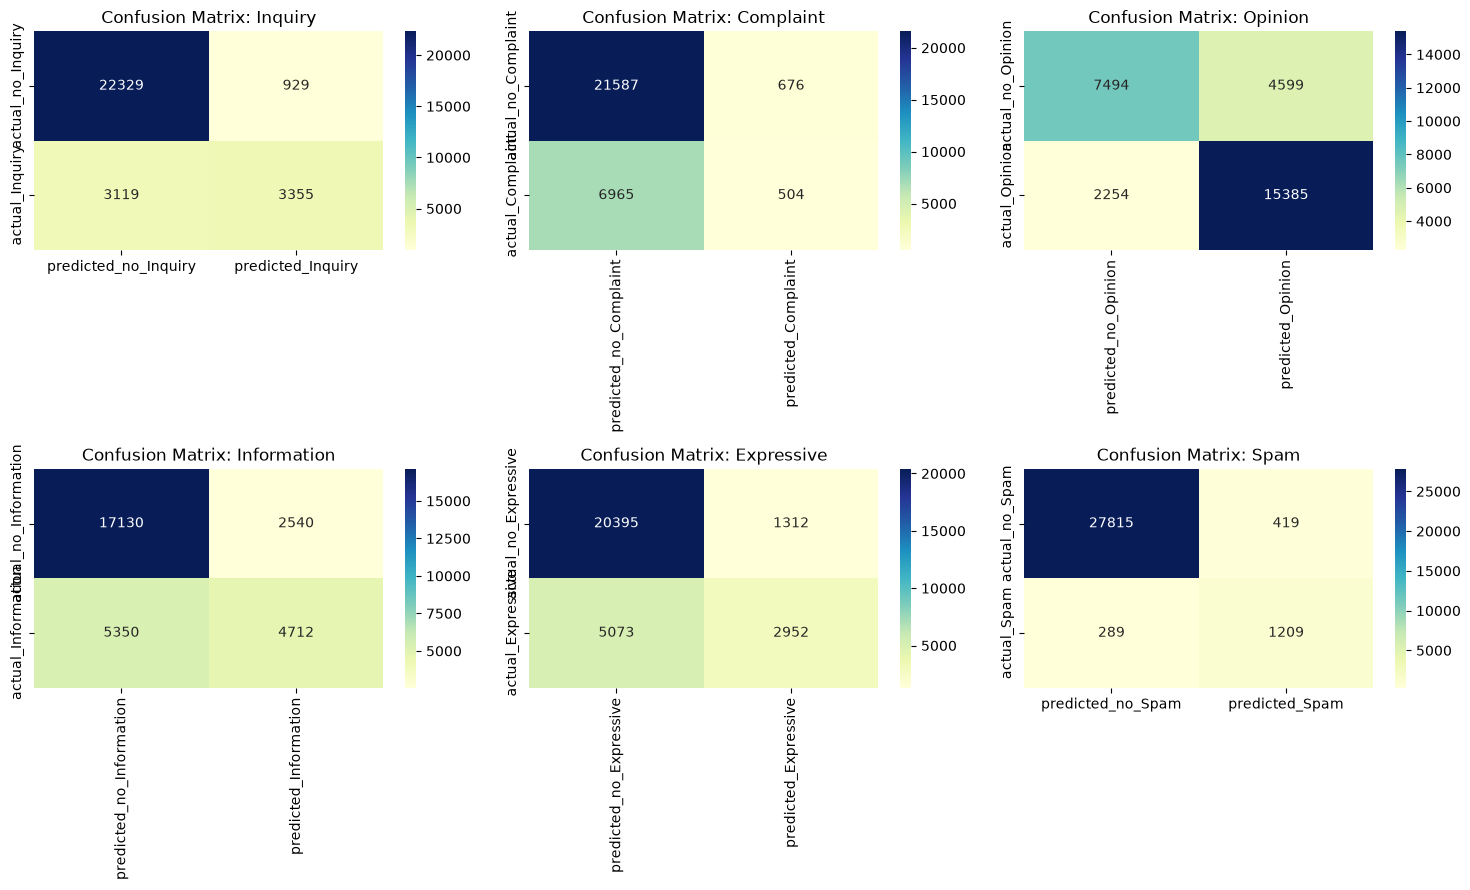


Overall Average F1 Score: 0.559



In [39]:
lr_f1_scores = evaluate_model("Logistic Regression", y_test, y_pred_lr, label_cols)

## 5.5 Random Forest Evaluation

RANDOM FOREST EVALUATION

--- Category: Inquiry ---
[22105  1153]
[2777  3697]
Accuracy:  0.868
Precision:  0.762
Recall:  0.571
F1 Score:  0.653

--- Category: Complaint ---
[22058  205]
[6929  540]
Accuracy:  0.76
Precision:  0.725
Recall:  0.072
F1 Score:  0.131

--- Category: Opinion ---
[7346  4747]
[1822  15817]
Accuracy:  0.779
Precision:  0.769
Recall:  0.897
F1 Score:  0.828

--- Category: Information ---
[17215  2455]
[4283  5779]
Accuracy:  0.773
Precision:  0.702
Recall:  0.574
F1 Score:  0.632

--- Category: Expressive ---
[20650  1057]
[5262  2763]
Accuracy:  0.787
Precision:  0.723
Recall:  0.344
F1 Score:  0.466

--- Category: Spam ---
[27825  409]
[227  1271]
Accuracy:  0.979
Precision:  0.757
Recall:  0.848
F1 Score:  0.8


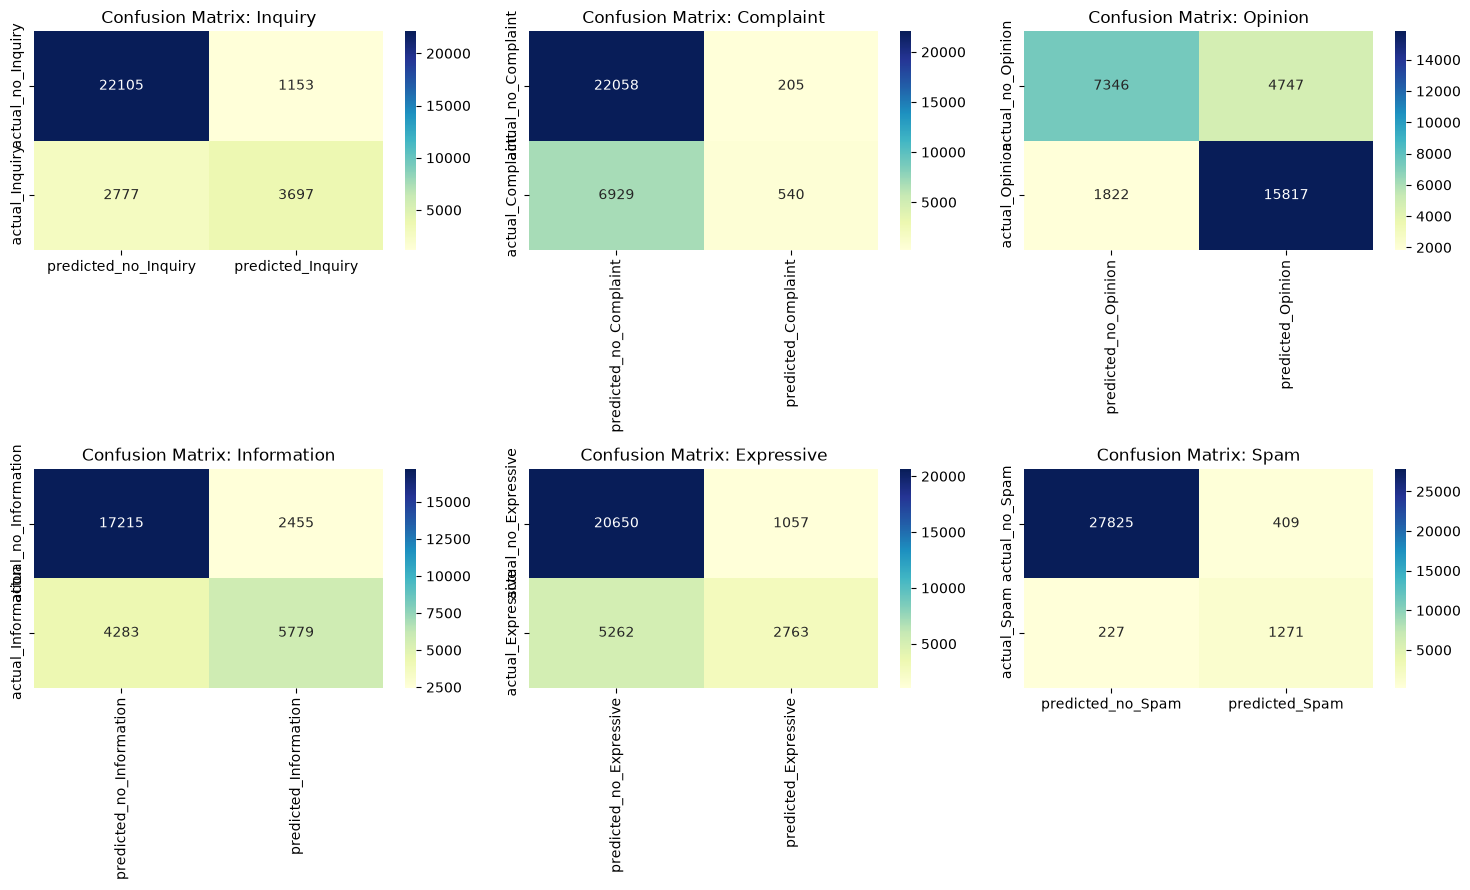


Overall Average F1 Score: 0.585



In [40]:
rf_f1_scores = evaluate_model("Random Forest", y_test, y_pred_rf, label_cols)

## 5.6 Model Comparison

In [41]:
comparison_df = pd.DataFrame({
    "Category": label_cols,
    "Logistic Regression F1": [f"{s:.3f}" for s in lr_f1_scores],
    "Random Forest F1": [f"{s:.3f}" for s in rf_f1_scores]
})

print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
display(comparison_df)

MODEL COMPARISON SUMMARY


,Category,Logistic Regression F1,Random Forest F1
0,Inquiry,0.624,0.653
1,Complaint,0.116,0.131
2,Opinion,0.818,0.828
3,Information,0.544,0.632
4,Expressive,0.480,0.466
5,Spam,0.774,0.800


# 6.0 Predict Unseen Data

## 6.1 Load Saved Models from Joblib

In [45]:
# Load the trained FastText feature extractor and both classifiers
loaded_ft = joblib.load('fasttext_model.joblib')
loaded_lr = joblib.load('logistic_regression_model.joblib')
loaded_rf = joblib.load('random_forest_model.joblib')

print("All models successfully loaded from joblib!")

All models successfully loaded from joblib!


## 6.2 Interactive Real-Time Forum Comment Prediction Loop

In [ ]:
print("=" * 65)
print("INTERACTIVE UNSEEN FORUM INTENT PREDICTOR")
print("Type your Manglish comment to test.")
print("Type 'exit' or 'q' to stop.")
print("=" * 65)

while True:
    user_input = input("\nEnter forum comment: ").strip()

    # Exit condition
    if user_input.lower() in ["exit", "q", "quit"]:
        print("Exiting prediction loop. Done!")
        break

    if not user_input:
        print("Input cannot be empty. Please enter a valid sentence.")
        continue

    # Step 1: Preprocess input text through existing Stage 1 pipeline
    text = mask_urls(user_input)
    text = mask_phone_numbers(text)
    text = mask_prices(text)
    text = mask_times(text)
    text = convert_emojis(text)
    text = to_lower(text)
    text = strip_non_latin(text)
    text = reduce_elongated(text)

    # Step 2: Slang normalization
    sentences = tokenize_sentences(text)
    norm_en = [normalize_slang_bulletproof(s) for s in sentences]
    norm_my = [normalize_malay_slang_bulletproof(s) for s in norm_en]

    # Step 3: Word tokenization & punctuation filtering
    tokens = []
    for s in norm_my:
        for t in tokenize_words(s):
            t_str = t.strip()
            if (
                (t_str.startswith("<") and t_str.endswith(">"))
                or t_str.isalnum()
                or t_str in KEEP_PUNCTUATION
            ):
                tokens.append(t_str)

    # Step 4: Extract FastText sentence embedding vector via Mean Pooling
    if tokens:
        vectors = [loaded_ft.wv[word] for word in tokens]
        vec = np.mean(vectors, axis=0).reshape(1, -1)
    else:
        vec = np.zeros((1, 100))

    # Step 5: Predict outcomes with both models
    lr_pred = loaded_lr.predict(vec)[0]
    rf_pred = loaded_rf.predict(vec)[0]

    lr_results = [label_cols[i] for i, val in enumerate(lr_pred) if val == 1]
    rf_results = [label_cols[i] for i, val in enumerate(rf_pred) if val == 1]

    # Output predictions
    print("-" * 50)
    print("Cleaned Tokens: ", tokens)
    print("Logistic Regression :", lr_results if lr_results else ["Neutral / None"])
    print("Random Forest       :", rf_results if rf_results else ["Neutral / None"])
    print("-" * 50)

INTERACTIVE UNSEEN FORUM INTENT PREDICTOR
Type your Manglish comment to test.
Type 'exit' or 'q' to stop.



Enter forum comment:  wow actually this is kinda cool


--------------------------------------------------
Cleaned Tokens:  ['wow', 'actually', 'this', 'is', 'kinda', 'hebat']
Logistic Regression : ['Opinion']
Random Forest       : ['Opinion', 'Expressive']
--------------------------------------------------



Enter forum comment:  anwar actually likes me


--------------------------------------------------
Cleaned Tokens:  ['anwar', 'actually', 'likes', 'me']
Logistic Regression : ['Opinion']
Random Forest       : ['Opinion']
--------------------------------------------------


...

--------------------------------------------------
Cleaned Tokens:  ['your', 'irs', 'tax', 'refund', 'is', 'pending', 'acceptance', 'must', 'accept', 'within', '24', 'hours', 'url']
Logistic Regression : ['Opinion', 'Information']
Random Forest       : ['Opinion', 'Information']
--------------------------------------------------



Enter forum comment:  Netflix: AJ, your subscription has expired. Renew now for just $1 a month: 62jjsm4.eeaar.com


--------------------------------------------------
Cleaned Tokens:  ['netflix', 'sahaja', 'your', 'subscription', 'has', 'tamat', 'tempoh', 'renew', 'now', 'for', 'just', 'price', 'a', 'month', 'url']
Logistic Regression : ['Opinion', 'Information']
Random Forest       : ['Opinion', 'Information']
--------------------------------------------------



Enter forum comment:  do anyone know how to do this


--------------------------------------------------
Cleaned Tokens:  ['do', 'anyone', 'know', 'how', 'to', 'do', 'this']
Logistic Regression : ['Neutral / None']
Random Forest       : ['Opinion']
--------------------------------------------------
